# Linear Regression from Scratch

A step-by-step implementation of Simple Linear Regression using Gradient Descent, 
built with no scikit-learn used in the modeling process.

This notebook covers:
- Exploring and preparing a synthetic dataset (`hours_studied` → `marks`)
- Implementing the prediction function, cost function, and gradients from scratch
- Training the model using gradient descent and visualizing convergence
- Evaluating performance on a held-out test set
- A note on feature standardization and why it matters for gradient descent

**Part of:** [ml-handson](https://github.com/syedyaser235/ml-handson) : practical implementations of core ML algorithms.

In [4]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt

### Dataset

Synthetic dataset relating `hours_studied` to `marks`, generated to simulate a realistic 
exam-performance scenario.

- **100 observations**
- `hours_studied`: ranges from 0 to 40
- `marks`: ranges from 0 to 100
- Correlation between the two: **~0.84** : a strong linear relationship with realistic noise

In [5]:
# reading sample data
df = pd.read_csv('data/weekly hours studied vs marks.csv')
print('Shape of DataFrame :',df.shape)
df.head(10)

Shape of DataFrame : (100, 2)


,Hours,Marks
0,40,98
1,37,40
2,28,68
3,12,33
4,15,80
5,33,80
6,24,63
7,39,99
8,17,42
9,22,50


In [6]:
# Null Check
print(df.dtypes)
print(df.isnull().sum())

Hours    int64
Marks    int64
dtype: object
Hours    0
Marks    0
dtype: int64


In [7]:
# Basic Statistics
df.describe()

,Hours,Marks
count,100.000000,100.000000
mean,20.780000,51.880000
std,11.136055,27.006651
min,0.000000,2.000000
25%,11.750000,30.000000
50%,20.500000,50.000000
75%,30.000000,74.500000
max,40.000000,100.000000


In [8]:
# Correlation between Hours and Marks
print('correlation :', df['Hours'].corr(df['Marks']))

correlation : 0.8476642071709332


Text(0, 0.5, 'Marks')

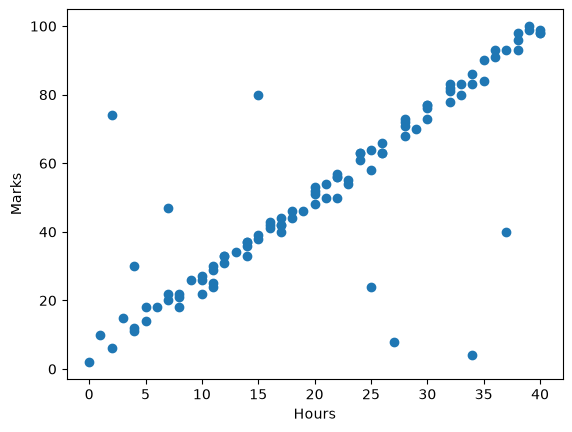

In [10]:
# plotting the data
plt.scatter(df['Hours'], df['Marks'])
plt.xlabel('Hours')
plt.ylabel('Marks')

## Train Test Split

In [ ]:

from sklearn.model_selection import train_test_split

X = df[['Hours']].values # keep X as 2D array 
y = df['Marks'].values #keeps y as 1D array 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(80, 1) (20, 1) (80,) (20,)


## Gradient Descent Algorithm

Linear regression assumes the relationship `ŷ = w·x + b`, where `w` and `b` are unknown 
parameters we need to learn from the data. 

Gradient Descent is the optimization algorithm used to find the best-fit `w` and `b` by 
minimizing the Mean Squared Error cost functiont. Starting from an initial guess, it 
iteratively updates `w` and `b` using their partial derivatives (gradients) with respect 
to the cost, taking small steps in the direction that reduces error the most.

**gradients** (partial derivatives) of the cost function:
w = w - alpha * (∂Cost/∂w)
b = b - alpha * (∂Cost/∂b)

where `alpha` (the learning rate) controls the size of each step. Repeating this process over 
many iterations (epochs) gradually moves `w` and `b` toward the values that minimize the 
cost i.e., the best-fit line.

In [101]:
#initialising parameters
w = 0.0 # weight of hours studied
b = 0.0 # bias 
alpha = 0.0001 # learning rate

def predict(X, w, b):
    """
    Compute predictions using the linear regression equation: y = w*X + b

    Parameters:
        X : input features (2D array, shape (n_samples, 1))
        w : weight/slope (scalar)
        b : bias/intercept (scalar)

    Returns:
        1D array of predicted values, shape (n_samples,)
    """
    y_pred = X * w + b   # apply the linear equation element-wise

    # flatten to 1D so it matches the shape of y_train/y_test (avoids
    # broadcasting issues later when computing errors/cost)
    return y_pred.flatten()


# Generate predictions on the training set using current w, b
y_pred = predict(X_train, w, b)

# Sanity check: preview first 5 predictions
print(y_pred[:5])

[0. 0. 0. 0. 0.]


In [103]:
def compute_cost(y_train, y_pred):
    """
    Compute the Mean Squared Error (MSE) between actual and predicted values.

    Parameters:
        y_train : actual target values (1D array, shape (n_samples,))
        y_pred  : predicted values (1D array, shape (n_samples,))

    Returns:
        Scalar cost value representing average squared error
    """
    n = len(y_train)  # number of training examples

    # MSE: average of squared differences between actual and predicted values
    cost = (1 / n) * sum((y_pred - y_train) ** 2)

    return cost


# Sanity check: cost using initial w, b (before training)
print("Cost:", compute_cost(y_train, y_pred))

Cost: 3340.5750000000003


In [104]:
def computegradient(X_train, y_train, y_pred):
    """
    Compute the gradients (partial derivatives) of the cost function
    with respect to w and b.

    Parameters:
        X_train : training input features (2D array, shape (n_samples, 1))
        y_train : actual target values (1D array, shape (n_samples,))
        y_pred  : predicted values (1D array, shape (n_samples,))

    Returns:
        dw : gradient of the cost with respect to w (scalar)
        db : gradient of the cost with respect to b (scalar)
    """
    n = len(y_train)  # number of training examples

    # gradient w.r.t. w: average of (error * corresponding x value)
    # flatten X_train since it's 2D (n,1) and needs to align with 1D error array
    dw = (1 / n) * sum((y_pred - y_train) * X_train.flatten())

    # gradient w.r.t. b: average of the error term alone
    db = (1 / n) * sum(y_pred - y_train)

    return dw, db


# Compute gradients using current predictions
dw, db = computegradient(X_train, y_train, y_pred)

print("dw:", dw)
print("db:", db)

dw: -1301.9250000000002
db: -51.425000000000004


In [71]:
w = w - alpha * dw
b = b - alpha * db

print("Updated weight after one iteration:", w)
print("Updated bias after one iteration:", b)

Updated weight after one iteration: 0.13019250000000002
Updated bias after one iteration: 0.0051425


In [105]:
# Function to train a Linear Regression model using Gradient Descent

def train_gradient_descent(X_train, y_train, w, b, alpha, epochs):
    """
    Train a simple linear regression model using batch gradient descent.

    Parameters:
        X_train : training input features (2D array, shape (n_samples, 1))
        y_train : actual target values (1D array, shape (n_samples,))
        w       : initial weight (scalar, typically 0)
        b       : initial bias (scalar, typically 0)
        alpha   : learning rate, controls the step size for each update
        epochs  : number of iterations to run gradient descent

    Returns:
        w      : final learned weight
        b      : final learned bias
        costs  : list of cost values recorded at every epoch (for plotting convergence)
    """
    costs = []  # track cost at every epoch, used later to plot the convergence curve

    for i in range(epochs):
        # Step 1: compute predictions using current w, b
        y_pred = predict(X_train, w, b)

        # Step 2: compute cost (MSE) for this epoch and store it
        cost = compute_cost(y_train, y_pred)
        costs.append(cost)

        # Step 3: compute gradients w.r.t. w and b
        dw, db = computegradient(X_train, y_train, y_pred)

        # Step 4: update parameters in the direction that reduces cost
        w = w - alpha * dw
        b = b - alpha * db

        # Print progress every 25 epochs to monitor convergence
        if i % 25 == 0:
            print(f"Epoch {i}: Cost {round(cost, 4)}, Weight {round(w, 4)}, Bias {round(b, 4)}")

    return round(w, 4), round(b, 4), costs

In [106]:
#reinitialising parameters
w = 0.0 # weight of hours studied
b = 0.0 # bias 
alpha = 0.0001 # learning rate
epochs = 500 # number of iterations

w, b, costs = train_gradient_descent(X_train, y_train, w, b, alpha, epochs)


Epoch 0: Cost 3340.575, Weight 0.1302, Bias 0.0051
Epoch 25: Cost 390.4575, Weight 1.8425, Bias 0.0754
Epoch 50: Cost 206.1313, Weight 2.2703, Bias 0.0972
Epoch 75: Cost 194.5922, Weight 2.377, Bias 0.1069
Epoch 100: Cost 193.8476, Weight 2.4036, Bias 0.1135
Epoch 125: Cost 193.7774, Weight 2.41, Bias 0.1194
Epoch 150: Cost 193.7493, Weight 2.4115, Bias 0.1251
Epoch 175: Cost 193.7239, Weight 2.4117, Bias 0.1307
Epoch 200: Cost 193.6987, Weight 2.4116, Bias 0.1363
Epoch 225: Cost 193.6736, Weight 2.4114, Bias 0.1419
Epoch 250: Cost 193.6484, Weight 2.4112, Bias 0.1475
Epoch 275: Cost 193.6233, Weight 2.411, Bias 0.1531
Epoch 300: Cost 193.5983, Weight 2.4108, Bias 0.1587
Epoch 325: Cost 193.5732, Weight 2.4106, Bias 0.1643
Epoch 350: Cost 193.5482, Weight 2.4104, Bias 0.1699
Epoch 375: Cost 193.5232, Weight 2.4102, Bias 0.1755
Epoch 400: Cost 193.4983, Weight 2.4099, Bias 0.1811
Epoch 425: Cost 193.4733, Weight 2.4097, Bias 0.1866
Epoch 450: Cost 193.4485, Weight 2.4095, Bias 0.1922
Ep

Text(0.5, 1.0, 'Cost vs Epoch')

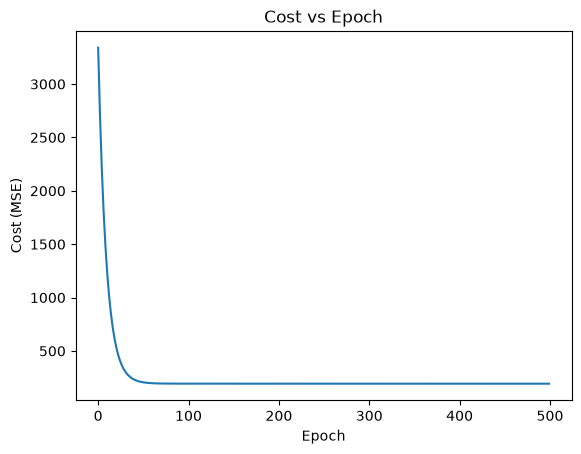

In [ ]:
# Plotting the cost function
plt.plot(range(epochs), costs)
plt.xlabel("Epoch")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs Epoch")

In [90]:
# testing the model on test data
y_test_pred = predict(X_test, w, b) 
#printing the predicted values
print("Predicted values:", y_test_pred)
test_cost = compute_cost(y_test, y_test_pred)
print("Test Cost:", test_cost)

Predicted values: [82.1125 19.4759 19.4759 72.4761 60.4306 19.4759 24.2941 67.6579 65.2488
 96.5671 60.4306 84.5216 33.9305 62.8397 17.0668 36.3396 48.3851 53.2033
 89.3398 77.2943]
Test Cost: 332.2996263205


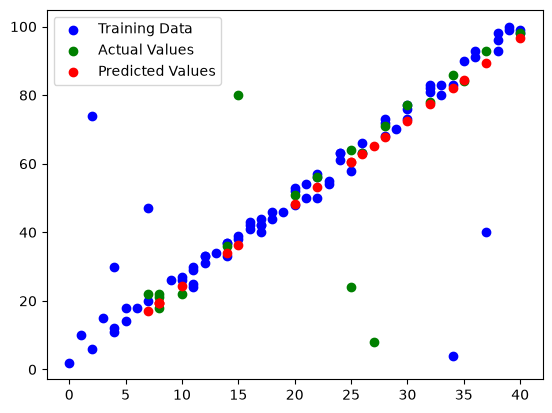

In [91]:
# Actual vs Predicted values plot along with training data

plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='green', label='Actual Values')
plt.scatter(X_test, y_test_pred, color='red', label='Predicted Values')
plt.legend()


In [88]:
# testing the model on test data
y_test_pred = predict(X_test, w, b)
# accuracy of the model
from sklearn.metrics import r2_score    
r2 = r2_score(y_test, y_test_pred)
print("R-squared value:", r2)

R-squared value: 0.5957474649694043


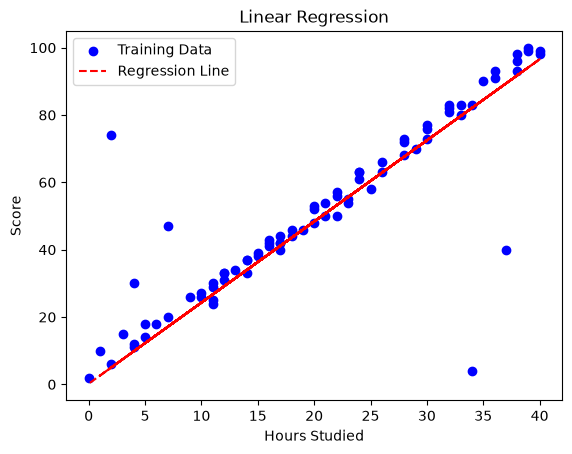

In [84]:
# regression line
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.plot(X_train, predict(X_train, w, b), color='red', label='Regression Line', linestyle='--')
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.title('Linear Regression')
plt.legend()
plt.show()

## Summary

This notebook implements **Simple Linear Regression from scratch** using gradient descent, 
without relying on scikit-learn for the modeling itself, to build intuition for how the 
algorithm actually works under the hood.

### Dataset
Synthetic data relating `hours_studied` (0–40) to `marks` (0–100), 100 observations, 
with a correlation of ~0.84 between the two, a strong linear relationship with realistic noise.

### What was done
1. **Exploratory checks** : verified shape, types, missing values, and visualized the 
   relationship via a scatter plot before modeling.
2. **Train/test split** : 80/20 split using `train_test_split` (data prep utility; not part 
   of the algorithm itself).
3. **Model built from scratch**:
   - `predict(X, w, b)` : computes `ŷ = w·x + b`
   - `compute_cost(y_true, y_pred)` : Mean Squared Error
   - `compute_gradients(X, y_true, y_pred)` : partial derivatives of cost w.r.t. `w` and `b`
   - Gradient descent loop : iteratively updated `w`, `b` using the gradients and a learning rate
4. **Training** : ran for 500 epochs, tracking cost at each step.
5. **Evaluation** : computed cost and R² on the held-out test set, and visualized the 
   fitted line and actual-vs-predicted values.

### Results
- Final weight (`w`): **~2.41**
- Final bias (`b`): **~0.20** *(still slowly converging, see note below)*
- Training cost (MSE): **~193.4**
- Test cost (MSE): **~332**
- Test R²: **~0.59**

**Interpretation**: each additional hour studied is associated with roughly **2.4 additional 
marks**. The model captures the overall trend well, but a handful of outliers in the test 
set (students who over- or under-performed relative to their study hours) account for most 
of the prediction error, visible clearly in the actual-vs-predicted plot.

---

### A note on Standardization (a step initially missed)

While training, I noticed something worth flagging: **`w` converged quickly (within ~100 
epochs), but `b` kept drifting slowly even after 500 epochs**, with cost barely improving 
in that tail.

**Why this happened**: `hours_studied` ranges up to 40 (unscaled), while gradients for `w` 
involve multiplying the error by `x` directly. This makes the cost surface an elongated, 
narrow valley, steep in the `w` direction, shallow in the `b` direction. Gradient descent 
naturally converges fast along steep directions and crawls along shallow ones, so `w` and 
`b` end up converging at very different rates using a single shared learning rate.

**The fix**: standardizing the input feature before training: x_scaled = (x - mean(x)) / std(x)
This reshapes the cost surface into a more symmetric bowl, so gradients for `w` and `b` 
become comparable in magnitude, letting both converge at similar, faster rates.

**Takeaway**: feature scaling isn't just a nice-to-have — it directly affects *how* gradient 
descent converges, especially when features have large or uneven scales. 